# Embeddings BERT Fine-tuned para Detección de Clickbait

Este notebook realiza:
1. Carga de librerías y datos
2. Fine-tuning de `bert-base-multilingual-cased` (título y cuerpo) — solo si no existe modelo guardado
3. Extracción de embeddings
4. Visualizaciones UMAP

El modelo se entrena como clasificador binario (num_labels=2) con la etiqueta cb como target. Es decir, los pesos del modelo aprenden a separar el clickbait de no-clickbait. Cuando luego se extrae el embedding `[CLS]`, se está sacando la representación de la red que ha sido optimizada para separarlo. Es por eso que el resultado de que se separe en el UMAP es lo esperable.

Con este análisis no se está demostrando una estructura interna de los datos.

Con este modelo analizo si las representaciones semánticas de BERT capturan la misma estructura que el modelo etiquetador, y qué características del texto explican esa estructura.

## 0. Configuración — Personaliza aquí los parámetros

In [30]:
# ============================================================
# RUTAS Y NOMBRES — editar aquí para nuevos datasets o modelos
# ============================================================

# Dataset
RUTA_DATOS = "data_processed/conjunto_noticias_2_limpio.json"

# Modelos fine-tuned
MODELO_TITULO_DIR    = "./bert_clickbait_titulo_finetuned"
MODELO_CONTENIDO_DIR = "./bert_clickbait_contenido_finetuned"

# Modelo base BERT
MODELO_BASE = "bert-base-multilingual-cased"

# Directorio de salida para gráficas
GRAFICAS_DIR = "img"

# Campos del JSON  ← cambiar si tu dataset usa otros nombres de campo
CAMPO_TITULO    = "Título"
CAMPO_CONTENIDO = "Contenido"
CAMPO_LABEL     = "cb"          # bool: True = clickbait
CAMPO_PERIODICO = "Periódico"
CAMPO_CATEGORIA = "Categoría"

# Hiperparámetros fine-tuning
MAX_LEN_TITULO    = 128
MAX_LEN_CONTENIDO = 512
BATCH_SIZE        = 16
EPOCHS_TITULO     = 5
EPOCHS_CONTENIDO  = 3
LEARNING_RATE     = 2e-5

# Hiperparámetros UMAP
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST    = 0.1

# Paleta de colores clickbait
COLOR_NO_CLICKBAIT = "#2E86AB"
COLOR_CLICKBAIT    = "#A23B72"

# Paleta de colores periódicos — añadir nuevos periódicos aquí
COLORES_PERIODICOS = {
    "El País":              "#0066CC",
    "El Mundo":             "#FF6600",
    "ABC":                  "#CC0000",
    "La Razón":             "#006633",
    "20 Minutos":           "#0DCE1D",
    "Público":              "#9900CC",
    "eldiario.es":          "#00CCFF",
    "Huffington Post":      "#FF00AA",
    "El Confidencial":      "#CC9900",
    "Mediterráneo Digital": "#009999",
}

# Paleta de colores categorías — añadir nuevas categorías aquí
COLORES_CATEGORIAS = {
    "Cultura":        "#32F593",
    "Nacional":       "#04696D",
    "Internacional":  "#FF00AA",
}

## 1. Librerías

In [31]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from umap import UMAP
from matplotlib.patches import Patch
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)
from datasets import Dataset

os.makedirs(GRAFICAS_DIR, exist_ok=True)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga de datos

In [32]:
with open(RUTA_DATOS, "r", encoding="utf-8") as f:
    noticias = json.load(f)

print(f"Noticias cargadas: {len(noticias)}")
print(f"Campos disponibles: {list(noticias[0].keys())}")

Noticias cargadas: 540
Campos disponibles: ['Link', 'Periódico', 'Fecha', 'Título', 'Subtítulo', 'Categoría', 'Contenido', 'cb', 'cb_score', 'cb_label']


## 3. Fine-tuning BERT

Si ya existe el modelo en disco, lo carga directamente. Si no, realiza el entrenamiento y lo guarda.

### 3.1 Funciones de fine-tuning

In [33]:
def preparar_dataset(noticias, campo_texto, campo_label=CAMPO_LABEL, test_size=0.2, seed=42):
    """Crea un HuggingFace Dataset con train/test split."""
    datos = {
        "text":  [n.get(campo_texto, "") for n in noticias],
        "label": [1 if n.get(campo_label) else 0 for n in noticias],
    }
    return Dataset.from_dict(datos).train_test_split(test_size=test_size, seed=seed)


def tokenizar_dataset(datasets, tokenizer, max_length):
    """Tokeniza el dataset completo."""
    def _tokenize(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=max_length)
    return datasets.map(_tokenize, batched=True)


def entrenar_modelo(noticias, campo_texto, output_dir, max_length, batch_size, epochs, learning_rate):
    """Entrena BERT para clasificación binaria y guarda el modelo."""
    print(f"\nEntrenando modelo para campo '{campo_texto}' → {output_dir}")

    tokenizer = AutoTokenizer.from_pretrained(MODELO_BASE)
    datasets  = preparar_dataset(noticias, campo_texto)
    datasets_tok = tokenizar_dataset(datasets, tokenizer, max_length)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODELO_BASE, num_labels=2, ignore_mismatched_sizes=True
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=datasets_tok["train"],
        eval_dataset=datasets_tok["test"],
    )

    trainer.train()
    model.save_pretrained(output_dir)
    tokenizer.save_pretrained(output_dir)
    print(f"Modelo guardado en {output_dir}")


def cargar_o_entrenar(noticias, campo_texto, output_dir, max_length, batch_size, epochs, learning_rate):
    """Carga el modelo si ya existe, si no lo entrena."""
    if os.path.isdir(output_dir) and os.listdir(output_dir):
        print(f"Modelo encontrado en '{output_dir}' → cargando sin entrenar.")
    else:
        entrenar_modelo(noticias, campo_texto, output_dir, max_length, batch_size, epochs, learning_rate)

    tokenizer = AutoTokenizer.from_pretrained(output_dir)
    model     = AutoModel.from_pretrained(output_dir)
    model.eval()
    return tokenizer, model

### 3.2 Cargar / entrenar modelo para Títulos

In [34]:
tokenizer_titulo, model_titulo = cargar_o_entrenar(
    noticias,
    campo_texto  = CAMPO_TITULO,
    output_dir   = MODELO_TITULO_DIR,
    max_length   = MAX_LEN_TITULO,
    batch_size   = BATCH_SIZE,
    epochs       = EPOCHS_TITULO,
    learning_rate= LEARNING_RATE,
)

Modelo encontrado en './bert_clickbait_titulo_finetuned' → cargando sin entrenar.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1872.39it/s]
[transformers] BertModel LOAD REPORT from: ./bert_clickbait_titulo_finetuned
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### 3.3 Cargar / entrenar modelo para Contenido

In [35]:
tokenizer_contenido, model_contenido = cargar_o_entrenar(
    noticias,
    campo_texto  = CAMPO_CONTENIDO,
    output_dir   = MODELO_CONTENIDO_DIR,
    max_length   = MAX_LEN_CONTENIDO,
    batch_size   = BATCH_SIZE // 2,   # batch más pequeño por longitud de texto
    epochs       = EPOCHS_CONTENIDO,
    learning_rate= LEARNING_RATE,
)

Modelo encontrado en './bert_clickbait_contenido_finetuned' → cargando sin entrenar.


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2098.58it/s]
[transformers] BertModel LOAD REPORT from: ./bert_clickbait_contenido_finetuned
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 4. Extracción de embeddings

In [36]:
def obtener_embeddings(textos, tokenizer, model, max_length, batch_size=32):
    """
    Extrae el embedding [CLS] para una lista de textos.
    Procesa en batches para no saturar la GPU/CPU.

    Returns
    -------
    np.ndarray  shape (n_textos, hidden_size)
    """
    all_embeddings = []

    for i in range(0, len(textos), batch_size):
        batch = textos[i: i + batch_size]
        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        with torch.no_grad():
            outputs = model(**inputs)
        cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(cls)

        if (i // batch_size + 1) % 10 == 0:
            print(f"  Batch {i // batch_size + 1}/{len(textos) // batch_size + 1}")

    return np.vstack(all_embeddings)

In [37]:
titulos    = [n.get(CAMPO_TITULO, "")    for n in noticias]
contenidos = [n.get(CAMPO_CONTENIDO, "") for n in noticias]
labels     = [n.get(CAMPO_LABEL, False)  for n in noticias]
periodicos = [n.get(CAMPO_PERIODICO, "") for n in noticias]
categorias = [n.get(CAMPO_CATEGORIA, "") for n in noticias]

print("Extrayendo embeddings de títulos...")
embeddings_titulo = obtener_embeddings(titulos, tokenizer_titulo, model_titulo, MAX_LEN_TITULO)

print("\nExtrayendo embeddings de contenido...")
embeddings_contenido = obtener_embeddings(contenidos, tokenizer_contenido, model_contenido, MAX_LEN_CONTENIDO)

print(f"\nShape títulos:   {embeddings_titulo.shape}")
print(f"Shape contenido: {embeddings_contenido.shape}")

Extrayendo embeddings de títulos...
  Batch 10/17

Extrayendo embeddings de contenido...
  Batch 10/17

Shape títulos:   (540, 768)
Shape contenido: (540, 768)


## 5. Reducción UMAP y visualizaciones

Las funciones de graficado reciben los embeddings y metadatos como parámetros, por lo que son fácilmente reutilizables con nuevos datos.

### 5.1 Funciones de visualización

In [38]:
def reducir_umap(embeddings, n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST, random_state=42):
    """Reduce embeddings a 2D con UMAP."""
    reducer = UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric="cosine",
        random_state=random_state,
    )
    return reducer.fit_transform(embeddings)


def _asignar_colores_faltantes(elementos, paleta):
    """Añade colores aleatorios a la paleta para elementos no definidos."""
    for elem in set(elementos):
        if elem not in paleta:
            paleta[elem] = f"#{np.random.randint(0, 0xFFFFFF):06x}"
    return paleta


def graficar_umap_clickbait(embeddings_2d, labels, titulo_grafica, guardar_como=None):
    """
    Jointplot UMAP coloreado por Clickbait / No Clickbait.

    Parámetros
    ----------
    embeddings_2d   : np.ndarray (N, 2)
    labels          : list[bool]  — True = clickbait
    titulo_grafica  : str
    guardar_como    : str|None    — ruta de guardado, ej. "img/titulo_clickbait.png"
    """
    df = pd.DataFrame({
        "UMAP 1":   embeddings_2d[:, 0],
        "UMAP 2":   embeddings_2d[:, 1],
        "Clickbait": ["Clickbait" if x else "No Clickbait" for x in labels],
    })

    sns.set_style("whitegrid")
    palette = {"No Clickbait": COLOR_NO_CLICKBAIT, "Clickbait": COLOR_CLICKBAIT}

    g = sns.jointplot(
        data=df, x="UMAP 1", y="UMAP 2",
        hue="Clickbait", kind="scatter",
        alpha=0.55, palette=palette,
        height=10, space=0.15, s=50,
        marginal_kws=dict(fill=True, common_norm=False, alpha=0.4),
    )

    g.fig.suptitle(titulo_grafica, fontsize=16, fontweight="bold", y=0.995)
    g.set_axis_labels("UMAP Dimensión 1", "UMAP Dimensión 2", fontsize=12, fontweight="bold")
    g.ax_joint.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)

    plt.tight_layout()
    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
        print(f"Guardado: {guardar_como}")
    plt.show()


def graficar_umap_periodico(embeddings_2d, periodicos, titulo_grafica, guardar_como=None):
    """
    Jointplot UMAP coloreado por periódico.

    Parámetros
    ----------
    embeddings_2d : np.ndarray (N, 2)
    periodicos    : list[str]
    titulo_grafica: str
    guardar_como  : str|None
    """
    paleta = _asignar_colores_faltantes(periodicos, dict(COLORES_PERIODICOS))

    df = pd.DataFrame({
        "UMAP 1":   embeddings_2d[:, 0],
        "UMAP 2":   embeddings_2d[:, 1],
        "Periódico": periodicos,
    })

    sns.set_style("whitegrid")
    g = sns.jointplot(
        data=df, x="UMAP 1", y="UMAP 2",
        hue="Periódico", kind="scatter",
        alpha=0.6, palette=paleta,
        height=10, space=0.2, s=50,
        marginal_kws=dict(fill=True, common_norm=False),
    )

    g.fig.suptitle(titulo_grafica, fontsize=16, fontweight="bold", y=0.995)
    g.set_axis_labels("UMAP Dimensión 1", "UMAP Dimensión 2", fontsize=12, fontweight="bold")

    handles, labs = g.ax_joint.get_legend_handles_labels()
    g.ax_joint.legend(handles, labs, title="Periódico", title_fontsize=11, fontsize=10, loc="upper right")
    g.ax_joint.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)

    plt.tight_layout()
    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
        print(f"Guardado: {guardar_como}")
    plt.show()


def graficar_umap_categoria(embeddings_2d, labels, categorias, titulo_grafica, guardar_como=None):
    """
    JointGrid UMAP con KDE de clickbait de fondo y scatter por categoría.

    Parámetros
    ----------
    embeddings_2d : np.ndarray (N, 2)
    labels        : list[bool]   — True = clickbait
    categorias    : list[str]
    titulo_grafica: str
    guardar_como  : str|None
    """
    paleta_cat = _asignar_colores_faltantes(categorias, dict(COLORES_CATEGORIAS))
    palette_cb = {"No Clickbait": COLOR_NO_CLICKBAIT, "Clickbait": COLOR_CLICKBAIT}

    df = pd.DataFrame({
        "UMAP 1":    embeddings_2d[:, 0],
        "UMAP 2":    embeddings_2d[:, 1],
        "Clickbait": ["Clickbait" if x else "No Clickbait" for x in labels],
        "Categoría": categorias,
    })

    sns.set_style("whitegrid")
    g = sns.JointGrid(data=df, x="UMAP 1", y="UMAP 2", height=10, space=0.15)

    # KDE de fondo por clickbait
    for cb, color in palette_cb.items():
        subset = df[df["Clickbait"] == cb]
        sns.kdeplot(data=subset, x="UMAP 1", y="UMAP 2",
                    fill=True, alpha=0.8, levels=6, color=color, ax=g.ax_joint)

    # Scatter por categoría
    for cat in df["Categoría"].unique():
        subset = df[df["Categoría"] == cat]
        g.ax_joint.scatter(
            subset["UMAP 1"], subset["UMAP 2"],
            label=cat, alpha=0.75, s=50,
            color=paleta_cat[cat], edgecolors="black", linewidth=0.4,
        )

    # Marginales por categoría
    for cat in df["Categoría"].unique():
        subset = df[df["Categoría"] == cat]
        sns.kdeplot(data=subset, x="UMAP 1", fill=True, alpha=0.35,
                    color=paleta_cat[cat], ax=g.ax_marg_x)
        sns.kdeplot(data=subset, y="UMAP 2", fill=True, alpha=0.35,
                    color=paleta_cat[cat], ax=g.ax_marg_y)

    g.fig.suptitle(titulo_grafica, fontsize=18, fontweight="bold", y=1.02)
    g.set_axis_labels("UMAP Dimensión 1", "UMAP Dimensión 2", fontsize=13, fontweight="bold")

    legend_cat = g.ax_joint.legend(
        title="Categoría", fontsize=10, title_fontsize=11, loc="upper right", frameon=True
    )
    g.ax_joint.add_artist(legend_cat)

    handles_cb = [
        Patch(facecolor=COLOR_NO_CLICKBAIT, edgecolor="none", alpha=0.8, label="No Clickbait"),
        Patch(facecolor=COLOR_CLICKBAIT,    edgecolor="none", alpha=0.8, label="Clickbait"),
    ]
    g.ax_joint.legend(handles=handles_cb, title="Clickbait", fontsize=10,
                      title_fontsize=11, loc="upper left", frameon=True)

    g.ax_joint.grid(True, alpha=0.3, linestyle="--", linewidth=0.5)
    sns.despine()
    plt.tight_layout()

    if guardar_como:
        plt.savefig(guardar_como, dpi=300, bbox_inches="tight")
        print(f"Guardado: {guardar_como}")
    plt.show()

### 5.2 Reducción UMAP

In [39]:
print("Calculando UMAP para títulos...")
umap_titulo = reducir_umap(embeddings_titulo)

print("Calculando UMAP para contenido...")
umap_contenido = reducir_umap(embeddings_contenido)

print("UMAP completado.")

Calculando UMAP para títulos...


/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calculando UMAP para contenido...


/home/javier/miniconda3/envs/NLP/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP completado.


### 5.3 Espacios Embebidos de Títulos — Análisis UMAP

Guardado: img/UMAP_titulos_clickbait.png


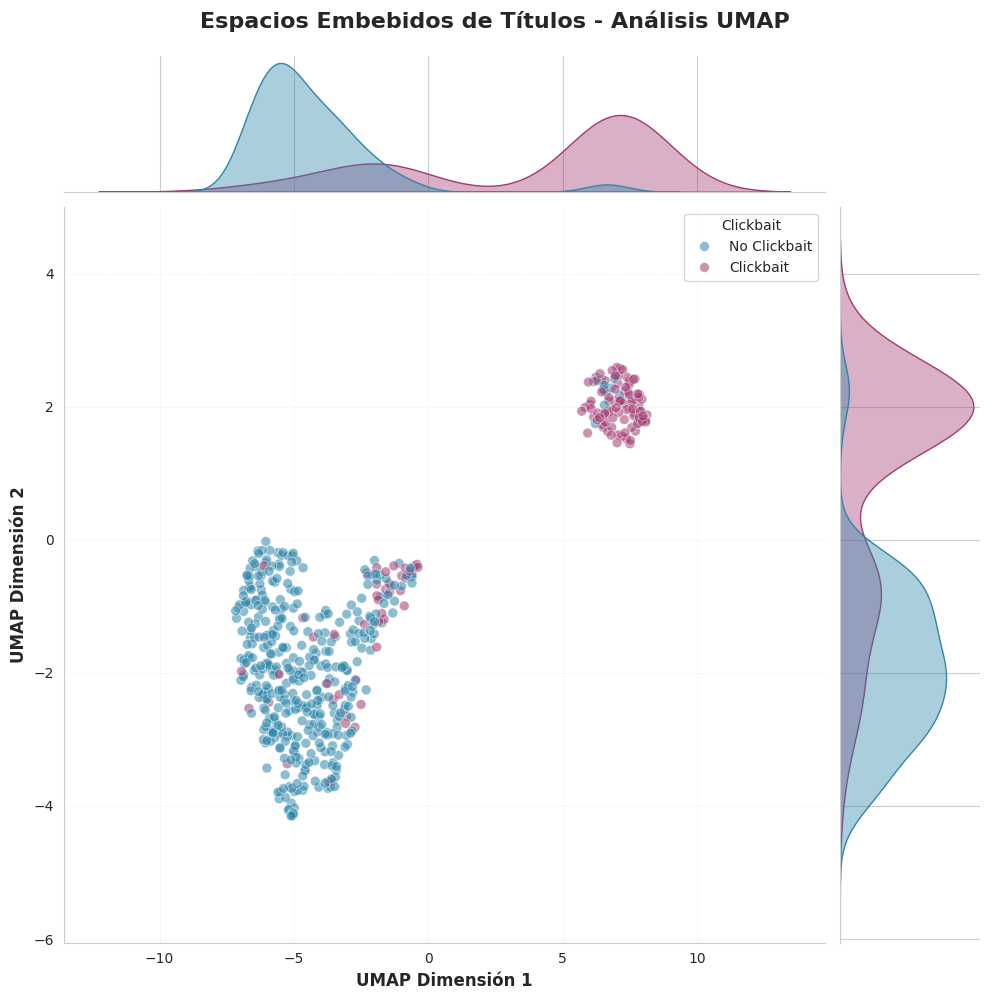

In [40]:
graficar_umap_clickbait(
    umap_titulo,
    labels,
    titulo_grafica="Espacios Embebidos de Títulos - Análisis UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_titulos_clickbait.png",
)

### 5.4 Espacios Embebidos de Contenido — Análisis UMAP

Guardado: img/UMAP_contenido_clickbait.png


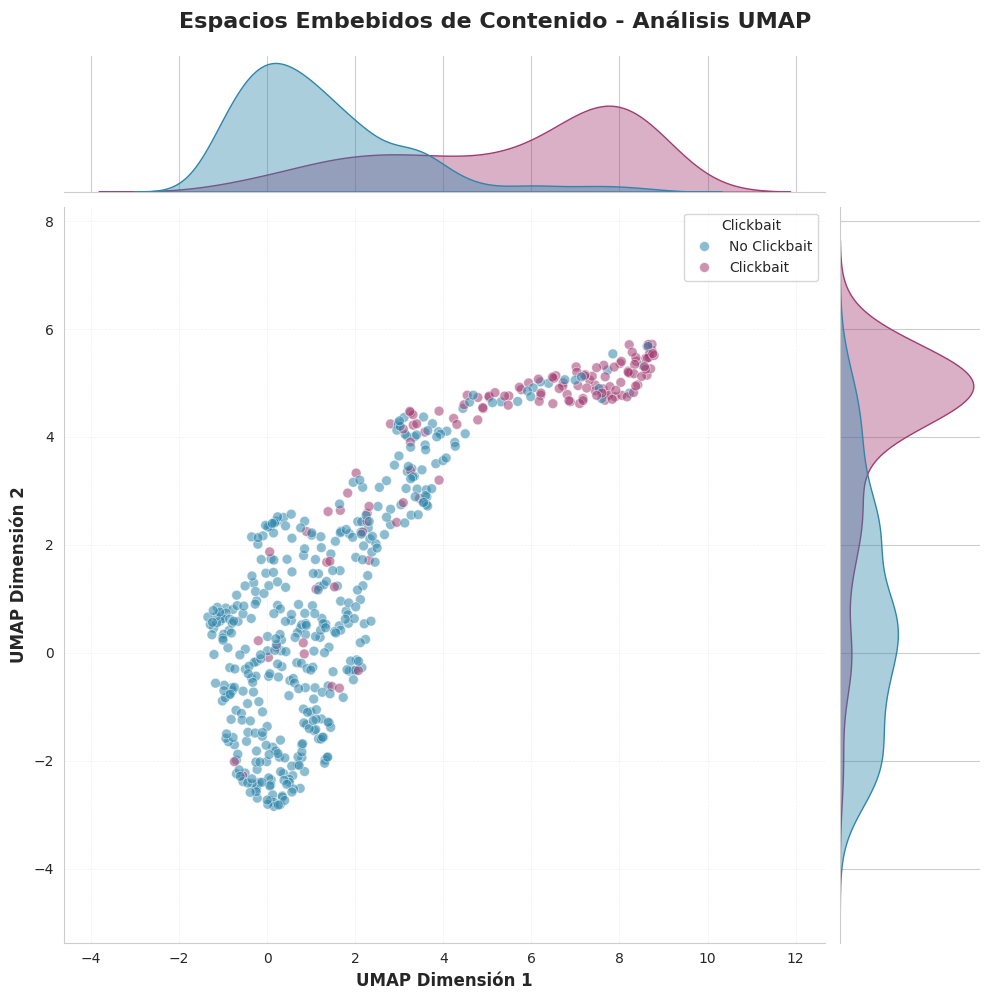

In [41]:
graficar_umap_clickbait(
    umap_contenido,
    labels,
    titulo_grafica="Espacios Embebidos de Contenido - Análisis UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_contenido_clickbait.png",
)

### 5.5 Espacios Embebidos de Contenido por Periódico — Análisis UMAP

Guardado: img/UMAP_contenido_periodico.png


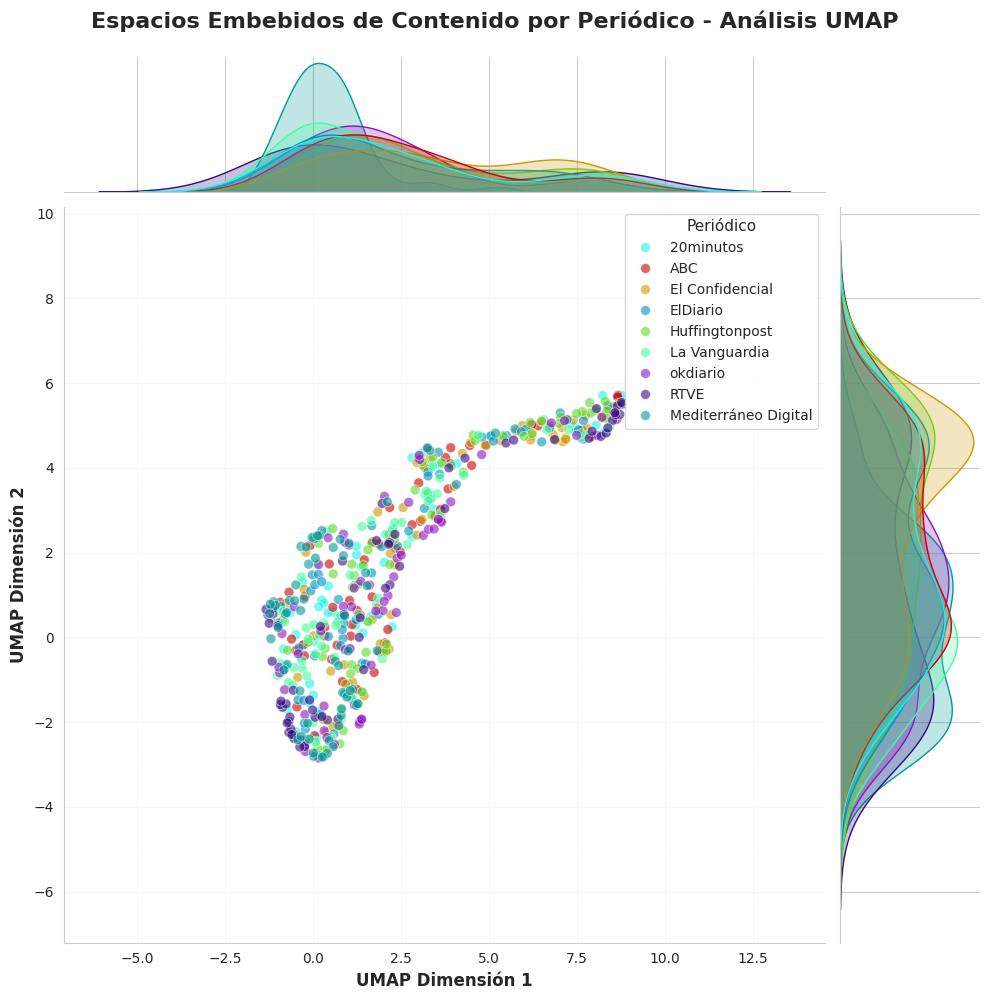

In [42]:
graficar_umap_periodico(
    umap_contenido,
    periodicos,
    titulo_grafica="Espacios Embebidos de Contenido por Periódico - Análisis UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_contenido_periodico.png",
)

### 5.6 Espacios Embebidos de Títulos por Periódico — Análisis UMAP

Guardado: img/UMAP_titulos_periodico.png


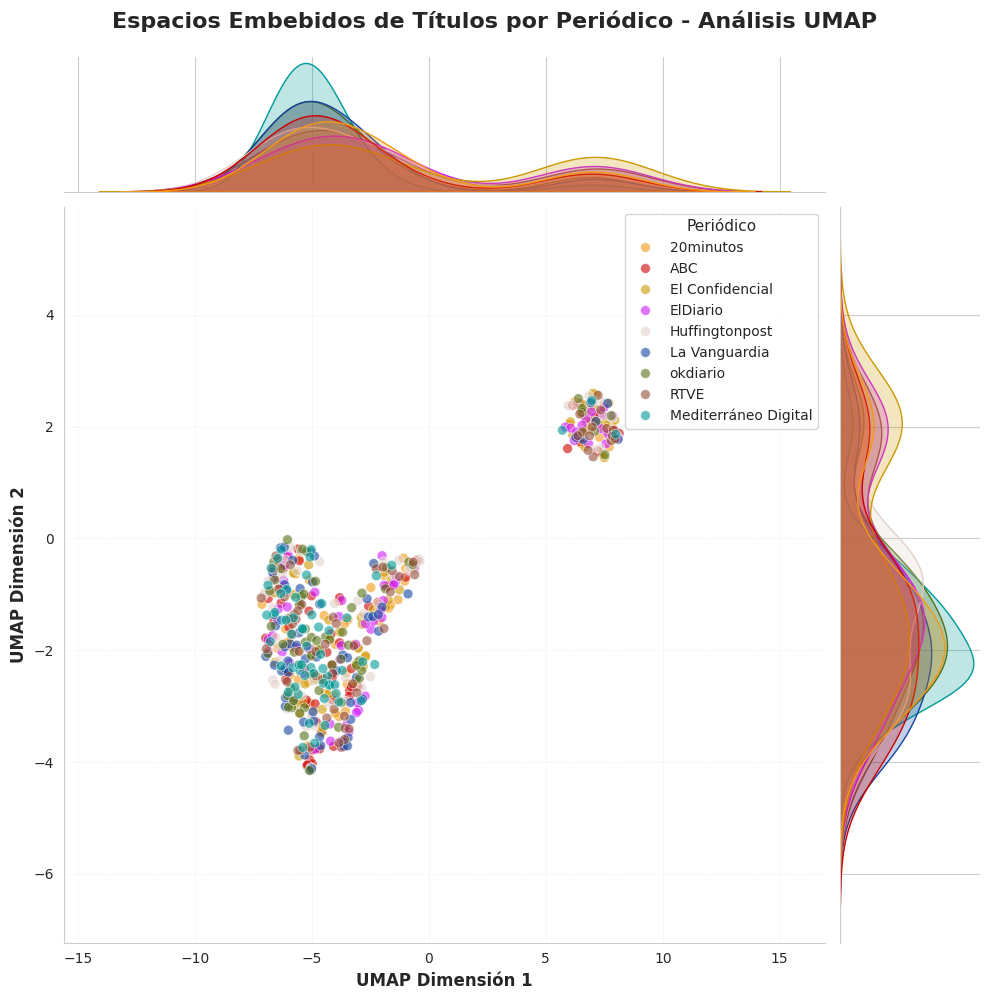

In [43]:
graficar_umap_periodico(
    umap_titulo,
    periodicos,
    titulo_grafica="Espacios Embebidos de Títulos por Periódico - Análisis UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_titulos_periodico.png",
)

### 5.7 Espacios Embebidos de Títulos — UMAP (KDE + categoría)

Guardado: img/UMAP_titulos_categoria.png


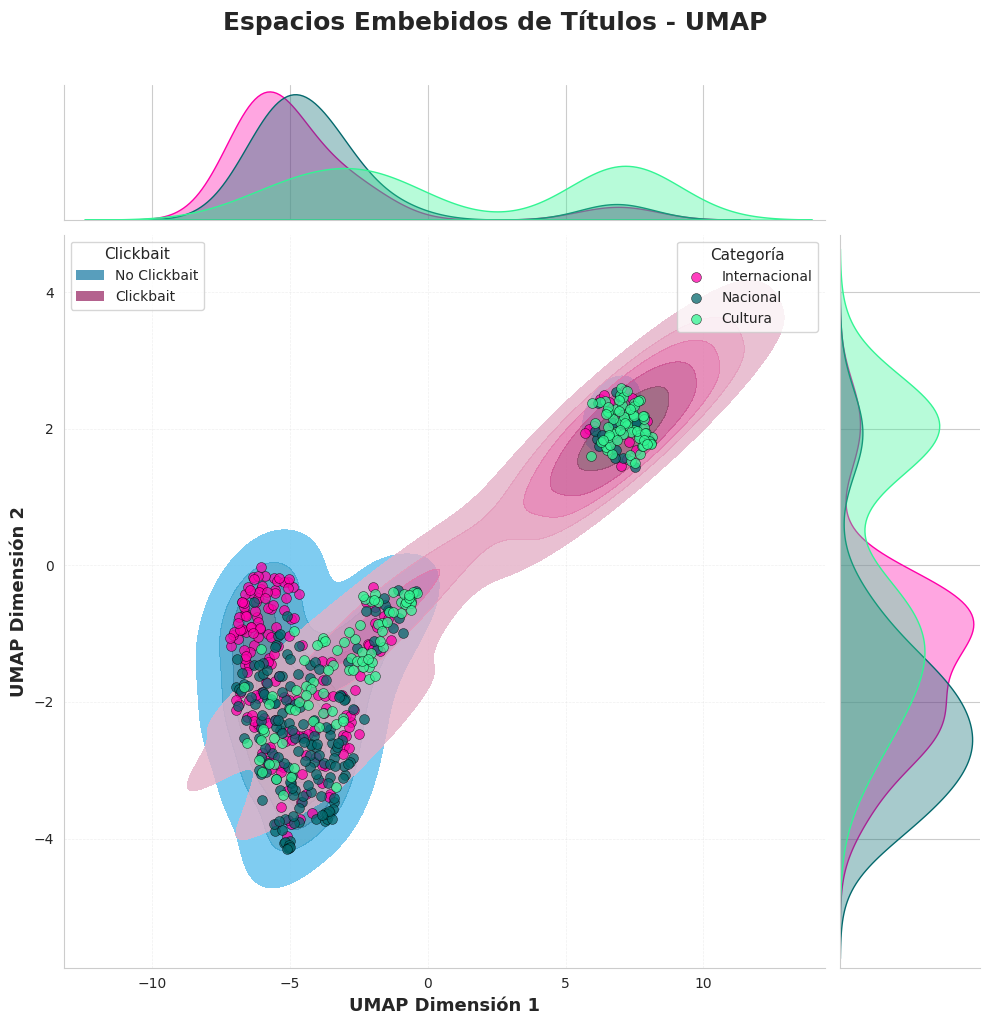

In [44]:
graficar_umap_categoria(
    umap_titulo,
    labels,
    categorias,
    titulo_grafica="Espacios Embebidos de Títulos - UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_titulos_categoria.png",
)

### 5.8 Espacios Embebidos de Contenido — UMAP (KDE + categoría)

Guardado: img/UMAP_contenido_categoria.png


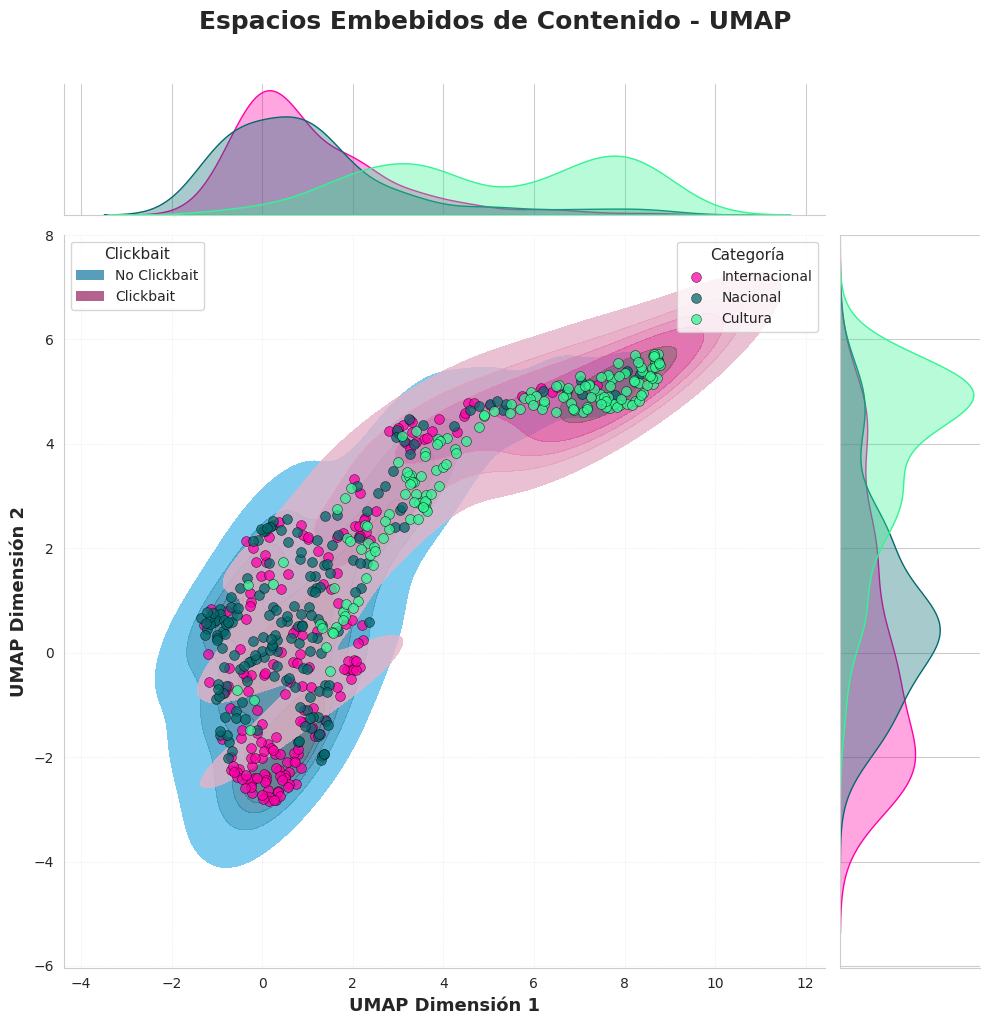

In [45]:
graficar_umap_categoria(
    umap_contenido,
    labels,
    categorias,
    titulo_grafica="Espacios Embebidos de Contenido - UMAP",
    guardar_como=f"{GRAFICAS_DIR}/UMAP_contenido_categoria.png",
)